# Pipeline Multiclasse — EDA + Engenharia de Atributos + RF, Regressão Logística e XGBoost

Notebook focado em modelos multiclasse nativos (RandomForest, Regressão
Logística e XGBoost), treinados diretamente nas 3 classes (`25%`, `50%`,
`75%`).

**Fluxo:**

1. Configuração e carregamento dos dados brutos
2. Limpeza (remove NOR e gravações curtas)
3. Engenharia de atributos (parametrizada por `n_bins` / `passo_pct`)
4. Funções genéricas: pipeline multiclasse, busca de hiperparâmetros,
   treino/avaliação (Leave-One-Rat-Out) e SHAP
5. RandomForest — pipeline completo
6. Regressão Logística — pipeline completo
7. XGBoost — pipeline completo
8. Teste de permutação (RF)

**Pipeline completo (aplicado a cada modelo, na seção correspondente):**

1. Escolhe o melhor `passo_pct` com busca de hiperparâmetros (grid mediano),
   sem seleção de features
2. Com o `passo_pct` vencedor, treina o modelo **com** e **sem** seleção de
   features (mesmo grid mediano) e fica com a variante de melhor
   `balanced_accuracy` em CV
3. Treina/avalia via Leave-One-Rat-Out e reporta as top features
4. Calcula e plota a importância SHAP do modelo final

**Nota:** a seleção de features, quando usada, fica sempre **dentro** do
`Pipeline` (refeita a cada fold de treino), para evitar vazamento de dados
entre treino e teste.


## 1. Configuração e Carregamento dos Dados

In [1]:
import json
import os
import time
import warnings
from pathlib import Path

os.environ["PYTHONWARNINGS"] = "ignore"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.base import clone
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)

try:
    import shap
    SHAP_DISPONIVEL = True
except ImportError:
    SHAP_DISPONIVEL = False
    print("Pacote 'shap' não encontrado. Instale com: pip install shap")

try:
    from xgboost import XGBClassifier
    XGBOOST_DISPONIVEL = True
except ImportError:
    XGBOOST_DISPONIVEL = False
    print("Pacote 'xgboost' não encontrado. Instale com: pip install xgboost")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=0.9)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

TOP_N_FEATURES_GRID = [10, 15, 20]

# Caminho do features_all 
CAMINHOS_CANDIDATOS = [
    Path("databases/features_all.csv"),
]

# Limite mínimo de duração do video (segundos)
DURACAO_MINIMA_S = 30

FEATURE_BOOLEANA = "pac_sl_alerta"
FEATURES_POR_AREA = [
    "mean", "std", "rms", "kurtosis", "skewness", "pico_a_pico", "pct_outlier_3s",
    "pot_delta", "pot_theta", "pot_beta", "pot_gamma_lento", "pot_gamma_rapido",
    "theta_gamma_lento_ratio", "theta_gamma_rapido_ratio", "delta_theta_ratio",
    "entropia_espectral", "centroide_hz",
    "pac_theta-gamma_rapido", "pac_theta-gamma_lento", "pac_sl_alerta",
]

# Grade de "pct" (tamanho da janela percentual) testada na escolha do melhor
PASSO_PCT_MAX = 50
PASSO_PCT_GRID = list(range(5, PASSO_PCT_MAX + 1, 5))
print(f"Candidatos de passo_pct a testar: {PASSO_PCT_GRID}")

CONDICOES_ALVO = [25, 50, 75]

caminho_dados = next((p for p in CAMINHOS_CANDIDATOS if p.exists()), None)
if caminho_dados is None:
    raise FileNotFoundError(
        "features_all não encontrado. Ajuste CAMINHOS_CANDIDATOS para apontar "
        "para o seu features_all.parquet ou features_all.csv."
    )

if caminho_dados.suffix == ".parquet":
    df_bruto = pd.read_parquet(caminho_dados)
else:
    df_bruto = pd.read_csv(caminho_dados)

print(f" Carregado: {caminho_dados}")
print(f"   Shape: {df_bruto.shape[0]:,} linhas × {df_bruto.shape[1]} colunas")


Candidatos de passo_pct a testar: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
✅ Carregado: databases/features_all.csv
   Shape: 19,285 linhas × 105 colunas


/home/joyceribeiro/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Limpeza dos Dados
Remove gravações do grupo NOR e arquivos com duração menor que o mínimo estipulado.

In [2]:
duracao_por_stem = df_bruto.groupby("stem")["segundo"].max()
stems_curtos = duracao_por_stem[duracao_por_stem < DURACAO_MINIMA_S]

n_arquivos_antes = df_bruto["stem"].nunique()

stems_nor = df_bruto.loc[
    df_bruto["stem"].str.contains("nor", case=False, na=False),
    "stem"
].unique()

df_limpo = df_bruto[~df_bruto["stem"].isin(stems_nor)].copy()
df_limpo = df_limpo[~df_limpo["stem"].isin(stems_curtos.index)].copy()

n_arquivos_depois = df_limpo["stem"].nunique()

print("=" * 60)
print(f"Arquivos antes das exclusões : {n_arquivos_antes}")
print(f"Arquivos NOR removidos       : {len(stems_nor)}")
print(f"Arquivos < {DURACAO_MINIMA_S}s removidos : {len(stems_curtos)}")
print(f"Arquivos após as exclusões   : {n_arquivos_depois}")
print("=" * 60)

AREAS = sorted({c[:-len("_mean")] for c in df_limpo.columns if c.endswith("_mean")})
print(f"\nÁreas anatômicas encontradas ({len(AREAS)}): {AREAS}")


Arquivos antes das exclusões : 94
Arquivos NOR removidos       : 22
Arquivos < 30s removidos : 3
Arquivos após as exclusões   : 69

Áreas anatômicas encontradas (4): ['CA3b', 'CA3c', 'DGD', 'DGV']


## 3. Engenharia de Atributos (parametrizada por `n_bins`)

Transforma o formato longo (1 linha por segundo) em formato largo (1 linha
por `arquivo × área`), calculando estatísticas (`mean`, `std`, `min`, `max`,
`median`) de cada feature dentro de janelas percentuais da gravação
(ex.: 10 janelas de 10% cada). Depois remove atributos redundantes
(|correlação| > 0.8).

In [3]:
def atribuir_faixa_percentual(n_segundos, n_bins):
    posicao_relativa = (np.arange(n_segundos) + 1) / n_segundos
    faixa = np.ceil(posicao_relativa * n_bins).astype(int)
    return np.clip(faixa, 1, n_bins)


def transformar_wide_por_arquivo_area(df_long, areas, features_por_area, n_bins):

    passo_pct = 100 // n_bins
    rotulos_pct = [passo_pct * b for b in range(1, n_bins + 1)]

    df_long = df_long.sort_values(["stem", "segundo"]).copy()

    linhas_resultado = []

    for stem, grupo in df_long.groupby("stem", sort=False):

        grupo = grupo.sort_values("segundo")
        grupo = grupo.assign(_faixa_pct=atribuir_faixa_percentual(len(grupo), n_bins))

        rato = grupo["rato"].iloc[0]
        trial = grupo["trial"].iloc[0]
        condicao = grupo["condicao"].iloc[0]

        for area in areas:

            col_ref = f"{area}_mean"
            area_registrada = col_ref in grupo.columns and grupo[col_ref].notna().any()
            if not area_registrada:
                continue

            linha = {
                "arquivo_area": f"{rato}_{trial}_{area}",
                "stem": stem, "rato": rato, "trial": trial,
                "condicao": condicao, "area": area, "duracao_s": len(grupo),
            }

            ESTATISTICAS_POR_JANELA = ["mean", "std", "min", "max", "median"]

            for feature in features_por_area:
                if feature == FEATURE_BOOLEANA:
                    continue

                coluna = f"{area}_{feature}"
                if coluna not in grupo.columns:
                    for pct in rotulos_pct:
                        for estat in ESTATISTICAS_POR_JANELA:
                            linha[f"{feature}_{estat}_{pct}pct"] = np.nan
                    continue

                for faixa, pct in zip(range(1, n_bins + 1), rotulos_pct):
                    valores = grupo.loc[grupo["_faixa_pct"] == faixa, coluna]
                    linha[f"{feature}_mean_{pct}pct"] = valores.mean()
                    linha[f"{feature}_std_{pct}pct"] = (
                        valores.std() if len(valores) > 1 else np.nan
                    )
                    linha[f"{feature}_min_{pct}pct"] = (
                        valores.min() if len(valores) else np.nan
                    )
                    linha[f"{feature}_max_{pct}pct"] = (
                        valores.max() if len(valores) else np.nan
                    )
                    linha[f"{feature}_median_{pct}pct"] = valores.median()

            coluna_bool = f"{area}_{FEATURE_BOOLEANA}"
            for faixa, pct in zip(range(1, n_bins + 1), rotulos_pct):
                if coluna_bool in grupo.columns:
                    valores = grupo.loc[grupo["_faixa_pct"] == faixa, coluna_bool]
                    linha[f"{FEATURE_BOOLEANA}_true_rate_{pct}pct"] = (
                        (valores == True).mean() if len(valores) else np.nan
                    )
                else:
                    linha[f"{FEATURE_BOOLEANA}_true_rate_{pct}pct"] = np.nan

            linhas_resultado.append(linha)

    return pd.DataFrame(linhas_resultado)


def remover_colunas_correlacionadas(X_ref, colunas_protegidas, limiar=0.8):
    """Identifica atributos com |correlação| > limiar (colunas protegidas ficam de fora)."""
    colunas_avaliar = [c for c in X_ref.columns if c not in colunas_protegidas]
    corr = X_ref[colunas_avaliar].corr().abs()
    mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
    upper = corr.where(mask)
    return [c for c in upper.columns if any(upper[c] > limiar)]


def montar_dataset_modelagem(df_long_limpo, passo_pct, verbose=True):
    """Reproduz a engenharia de atributos completa (transformação wide +
    remoção de correlacionados) para um dado `passo_pct` (ex.: 5, 10, 15, ...).

    Retorna X_final, y (condicao 0.25/0.5/0.75), groups (rato) e a lista de
    colunas removidas por correlação.
    """
    n_bins = max(1, round(100 / passo_pct))

    df_pct = transformar_wide_por_arquivo_area(
        df_long_limpo, AREAS, FEATURES_POR_AREA, n_bins=n_bins
    )

    features_continuas = [f for f in FEATURES_POR_AREA if f != FEATURE_BOOLEANA]
    passo_pct_real = 100 // n_bins
    pcts = [passo_pct_real * b for b in range(1, n_bins + 1)]

    for feature in features_continuas:
        cols = [f"{feature}_mean_{p}pct" for p in pcts]
        df_pct[f"{feature}_media_geral"] = df_pct[cols].mean(axis=1)

    df_pct["pac_sl_alerta_taxa_geral"] = df_pct[
        [f"pac_sl_alerta_true_rate_{p}pct" for p in pcts]
    ].mean(axis=1)

    df_pct["condicao"] = pd.to_numeric(df_pct["condicao"])

    df_pct = df_pct.drop(columns=["trial", "duracao_s", "stem", "arquivo_area"])
    df_pct = pd.get_dummies(df_pct, columns=["area"], prefix="area", dtype=int)

    groups = df_pct["rato"]
    y = df_pct["condicao"]
    X = df_pct.drop(columns=["rato", "condicao"], errors="ignore")

    colunas_protegidas = [c for c in X.columns if c.startswith("area_")]
    colunas_removidas = remover_colunas_correlacionadas(X, colunas_protegidas)
    features_finais = [c for c in X.columns if c not in colunas_removidas]
    X_final = X[features_finais]

    if verbose:
        print(f"[passo_pct={passo_pct} -> n_bins={n_bins}] "
              f"atributos: {X.shape[1]} -> {X_final.shape[1]} "
              f"({len(colunas_removidas)} removidos por correlação)")

    return X_final, y, groups, colunas_removidas, n_bins


print("Funções de engenharia de atributos definidas.")


Funções de engenharia de atributos definidas.


## 4. Funções Genéricas de Pipeline Multiclasse

`StandardScaler` →`SelectFromModel` → classificador, com busca de
hiperparâmetros (`GridSearchCV` exaustivo), avaliação (Leave-One-Rat-Out) e SHAP — funções genéricas que funcionam para
`RandomForestClassifier`, `LogisticRegression` e `XGBClassifier`.

In [4]:
def montar_pipeline_multiclasse(estimator, usar_selecao_features=True, selector_estimator=None):
    """Pipeline genérico: StandardScaler -> SelectFromModel -> estimator.

    A seleção de features fica DENTRO do pipeline, então é refeita em cada fold
    do Leave-One-Rat-Out (fit somente no treino) -- sem vazamento de dados do
    teste para a escolha de quais features usar.
    """
    passos = [("scaler", StandardScaler())]
    if usar_selecao_features:
        sel_est = selector_estimator or RandomForestClassifier(
            n_estimators=300, max_depth=5, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1,
        )
        passos.append(("selector", SelectFromModel(sel_est, threshold=-np.inf, max_features=20)))
    passos.append(("clf", estimator))
    return Pipeline(passos)


def _scorer_balanced_accuracy_silencioso(estimator, X, y):
    """Mesma métrica de `scoring="balanced_accuracy"`, mas silenciando o
    UserWarning "y_pred contains classes not in y_true" -- esperado no
    Leave-One-Rat-Out, onde um fold de validação pode não conter todas as
    classes."""
    y_pred = estimator.predict(X)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        return balanced_accuracy_score(y, y_pred)


def escolher_melhores_hiperparametros_multi(X, y_multi, groups, logo, estimator, param_grid,
                                             usar_selecao_features=True, selector_estimator=None,
                                             rotulo="modelo"):
    """Busca exaustiva de hiperparâmetros (GridSearchCV) com cv=LeaveOneGroupOut
    sobre o pipeline completo (scaler + seleção de features + classificador)."""
    pipe = montar_pipeline_multiclasse(estimator, usar_selecao_features, selector_estimator)
    cv_splits = list(logo.split(X, y_multi, groups=groups))

    n_combinacoes = 1
    for valores in param_grid.values():
        n_combinacoes *= len(valores)

    print(f"  [{rotulo}] grid com {n_combinacoes} combinacoes -> GridSearchCV exaustivo")
    busca = GridSearchCV(
        pipe, param_grid=param_grid, scoring=_scorer_balanced_accuracy_silencioso,
        cv=cv_splits, n_jobs=-1, refit=True,
    )

    busca.fit(X, y_multi)
    melhores_params = dict(busca.best_params_)
    print(f"  [{rotulo}] melhor balanced_accuracy (CV): {busca.best_score_:.3f} | params: {melhores_params}")
    return melhores_params, busca


def treinar_avaliar_multiclasse(X, y_multi, groups, logo, estimator, melhores_params,
                                 usar_selecao_features=True, selector_estimator=None,
                                 rotulo="modelo", labels_multi=None):
    """Treina/avalia um classificador multiclasse nativo com Leave-One-Rat-Out.
    Seleção de features (se usada) é refeita em cada fold, ajustada só no treino."""
    labels_multi = list(labels_multi) if labels_multi is not None else list(CONDICOES_ALVO)
    resultados_fold = []
    matriz_confusao_soma = np.zeros((len(labels_multi), len(labels_multi)), dtype=int)
    importancias_fold = []
    n_folds = logo.get_n_splits(groups=groups)

    for fold_i, (idx_tr, idx_te) in enumerate(logo.split(X, y_multi, groups=groups), start=1):
        rato_teste = groups.iloc[idx_te].unique()[0]
        X_tr, X_te = X.iloc[idx_tr], X.iloc[idx_te]
        y_tr, y_te = y_multi.iloc[idx_tr], y_multi.iloc[idx_te]

        pipe = montar_pipeline_multiclasse(clone(estimator), usar_selecao_features, selector_estimator)
        pipe.set_params(**melhores_params)
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)

        # balanced_accuracy_score nao aceita "labels" (diferente de f1/precision/recall);
        # em folds pequenos do LOGO e comum y_pred conter classes ausentes em y_te
        # (o modelo foi treinado com as 3 classes), o que gera um UserWarning benigno.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=UserWarning)
            bal_acc = balanced_accuracy_score(y_te, y_pred)
        f1_macro = f1_score(y_te, y_pred, labels=labels_multi, average="macro", zero_division=0)
        precision_macro = precision_score(y_te, y_pred, labels=labels_multi, average="macro", zero_division=0)
        recall_macro = recall_score(y_te, y_pred, labels=labels_multi, average="macro", zero_division=0)
        cm = confusion_matrix(y_te, y_pred, labels=labels_multi)
        matriz_confusao_soma += cm

        resultados_fold.append({
            "fold": fold_i, "rato_teste": rato_teste, "n_amostras_teste": len(idx_te),
            "balanced_accuracy": bal_acc, "f1_macro": f1_macro,
            "precision_macro": precision_macro, "recall_macro": recall_macro,
        })

        if usar_selecao_features and "selector" in pipe.named_steps:
            feats_selecionadas = X_tr.columns[pipe.named_steps["selector"].get_support()]
        else:
            feats_selecionadas = X_tr.columns

        clf_fit = pipe.named_steps["clf"]
        if hasattr(clf_fit, "feature_importances_"):
            imp = pd.Series(clf_fit.feature_importances_, index=feats_selecionadas)
        elif hasattr(clf_fit, "coef_"):
            imp = pd.Series(np.abs(clf_fit.coef_).mean(axis=0), index=feats_selecionadas)
        else:
            imp = pd.Series(dtype=float)
        importancias_fold.append(imp)

        print(f"    [{rotulo}] fold {fold_i}/{n_folds} -- teste = rato {rato_teste} "
              f"(n={len(idx_te)}) | bal_acc={bal_acc:.3f} | f1_macro={f1_macro:.3f}")

    df_resultados = pd.DataFrame(resultados_fold)
    df_importancias = pd.concat(importancias_fold, axis=1).fillna(0)
    df_importancias.columns = [f"fold_{i+1}" for i in range(len(importancias_fold))]
    resumo_importancias = pd.DataFrame({
        "media": df_importancias.mean(axis=1), "desvio_padrao": df_importancias.std(axis=1),
    }).sort_values("media", ascending=False)

    return {
        "rotulo": rotulo, "df_resultados": df_resultados,
        "matriz_confusao_soma": matriz_confusao_soma,
        "resumo_importancias": resumo_importancias,
        "labels": [f"{l}%" for l in labels_multi],
    }


def relatar_modelo_multiclasse(saida, titulo):
    """Imprime métricas e plota a matriz de confusão 3x3 + top features (importância)."""
    df_resultados = saida["df_resultados"]

    print(f"\n=== Resumo -- {titulo} ===")
    print(f"Acurácia balanceada: {df_resultados['balanced_accuracy'].mean():.3f}"
          f" ± {df_resultados['balanced_accuracy'].std():.3f}")
    print(f"F1 macro       : {df_resultados['f1_macro'].mean():.3f}"
          f" ± {df_resultados['f1_macro'].std():.3f}")
    print(f"Precision macro: {df_resultados['precision_macro'].mean():.3f}"
          f" ± {df_resultados['precision_macro'].std():.3f}")
    print(f"Recall macro   : {df_resultados['recall_macro'].mean():.3f}"
          f" ± {df_resultados['recall_macro'].std():.3f}")

    cm = saida["matriz_confusao_soma"]
    labels_plot = saida["labels"]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    ax_cm = axes[0]
    im = ax_cm.imshow(cm, cmap="Blues")
    ax_cm.set_xticks(range(len(labels_plot))); ax_cm.set_xticklabels(labels_plot)
    ax_cm.set_yticks(range(len(labels_plot))); ax_cm.set_yticklabels(labels_plot)
    ax_cm.set_xlabel("Predito"); ax_cm.set_ylabel("Real")
    ax_cm.set_title(f"Matriz de confusão -- {titulo}")
    limiar = cm.max() / 2 if cm.max() else 1
    for i in range(len(labels_plot)):
        for j in range(len(labels_plot)):
            ax_cm.text(j, i, cm[i, j], ha="center", va="center",
                       color="white" if cm[i, j] > limiar else "black")
    fig.colorbar(im, ax=ax_cm, label="n° de amostras")

    ax_imp = axes[1]
    top = saida["resumo_importancias"].head(12).iloc[::-1]
    ax_imp.barh(top.index, top["media"], xerr=top["desvio_padrao"], color="#4C72B0")
    ax_imp.set_xlabel("Importância média")
    ax_imp.set_title(f"Top 12 features -- {titulo}")

    plt.tight_layout()
    plt.show()


def calcular_e_plotar_shap(pipe, X, rotulo, max_amostras=200):
    """Calcula os valores SHAP do classificador final (já treinado em todos os
    dados) e plota as top-15 features por |SHAP| médio.

    Usa `shap.Explainer` genérico, que seleciona automaticamente o algoritmo
    adequado ao tipo de modelo (TreeExplainer para RF/XGBoost, LinearExplainer
    para Regressão Logística etc.).
    """
    if not SHAP_DISPONIVEL:
        print(f"[{rotulo}] shap não disponível -- pulando etapa de SHAP.")
        return None

    X_proc = X
    for _, passo in pipe.steps[:-1]:
        X_proc = passo.transform(X_proc)
    selector = pipe.named_steps.get("selector")
    feats = X.columns[selector.get_support()] if selector is not None else X.columns
    X_proc = pd.DataFrame(np.asarray(X_proc), columns=feats, index=X.index)

    n_amostra = min(max_amostras, len(X_proc))
    X_amostra = X_proc.sample(n_amostra, random_state=RANDOM_STATE) if len(X_proc) > n_amostra else X_proc

    clf = pipe.named_steps["clf"]
    explainer = shap.Explainer(clf, X_proc)
    valores_shap = explainer(X_amostra)

    valores = valores_shap.values
    valores_abs_medios = (
        np.abs(valores).mean(axis=(0, 2)) if valores.ndim == 3 else np.abs(valores).mean(axis=0)
    )
    resumo_shap = pd.Series(valores_abs_medios, index=feats).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(7, 5))
    top_shap = resumo_shap.head(15).iloc[::-1]
    ax.barh(top_shap.index, top_shap.values, color="#55A868")
    ax.set_xlabel("|SHAP| médio")
    ax.set_title(f"Top 15 features (SHAP) -- {rotulo}")
    plt.tight_layout()
    plt.show()

    return resumo_shap


def pipeline_completo_modelo(df_long_limpo, nome_modelo, estimator, param_grid_semsel, param_grid_comsel,
                              passo_pct_grid=None, y_transformer=None, inverse_label_fn=None,
                              calcular_shap_flag=True, shap_max_amostras=200):
    passo_pct_grid = passo_pct_grid or PASSO_PCT_GRID
    logo = LeaveOneGroupOut()
    y_transformer = y_transformer or (lambda y: y)

    # --- Etapa 1: escolha do passo_pct (grid mediano, sem seleção de features) ---
    print(f"\n{'#'*70}\n# {nome_modelo} -- Etapa 1/4: escolha de passo_pct (grid mediano)\n{'#'*70}")
    resultados_pct = []
    buscas_por_pct = {}  # guarda (params, busca, X, y, groups) de cada pct -- reaproveitado na Etapa 2
    for passo_pct in passo_pct_grid:
        t0 = time.time()
        X_pct, y_pct, groups_pct, _, n_bins = montar_dataset_modelagem(df_long_limpo, passo_pct, verbose=False)
        y_pct_multi = y_transformer((y_pct * 100).round().astype(int))

        params_pct, busca_pct = escolher_melhores_hiperparametros_multi(
            X_pct, y_pct_multi, groups_pct, logo, estimator=clone(estimator),
            param_grid=param_grid_semsel, usar_selecao_features=False,
            rotulo=f"{nome_modelo} [passo_pct={passo_pct}]",
        )
        buscas_por_pct[passo_pct] = (params_pct, busca_pct, X_pct, y_pct_multi, groups_pct)
        resultados_pct.append({
            "passo_pct": passo_pct, "n_bins": n_bins, "n_atributos": X_pct.shape[1],
            "balanced_accuracy_cv": busca_pct.best_score_,
        })
        print(f"[{nome_modelo}] passo_pct={passo_pct} concluído em {(time.time() - t0) / 60:.1f} min")

    df_busca_pct = pd.DataFrame(resultados_pct).sort_values("balanced_accuracy_cv", ascending=False)
    melhor_passo_pct = int(df_busca_pct.iloc[0]["passo_pct"])
    print(f"\n[{nome_modelo}] melhor passo_pct: {melhor_passo_pct}% "
          f"(balanced_accuracy CV = {df_busca_pct.iloc[0]['balanced_accuracy_cv']:.4f})")

    df_plot = df_busca_pct.sort_values("passo_pct")
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(df_plot["passo_pct"], df_plot["balanced_accuracy_cv"], marker="o")
    ax.axvline(melhor_passo_pct, color="gray", linestyle=":", alpha=0.7)
    ax.axhline(1 / 3, color="black", linestyle=":", alpha=0.5, label="chance (1/3)")
    ax.set_xlabel("passo_pct (%)"); ax.set_ylabel("balanced_accuracy (CV)")
    ax.set_title(f"Escolha de passo_pct -- {nome_modelo}")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --- Etapa 2: com vs. sem seleção de features, para o passo_pct vencedor ---
    # "sem seleção" já foi calculada na Etapa 1 para o passo_pct vencedor -- reaproveita.
    params_semsel, busca_semsel, X_final, y_multi, groups = buscas_por_pct[melhor_passo_pct]
    labels_multi = sorted(y_multi.unique())

    print(f"\n{'#'*70}\n# {nome_modelo} -- Etapa 2/4: com vs. sem seleção de features\n{'#'*70}")
    print(f"--- sem seleção de features (reaproveitado da Etapa 1, passo_pct={melhor_passo_pct}%) ---")
    print(f"  [{nome_modelo} [sem seleção]] balanced_accuracy (CV): {busca_semsel.best_score_:.3f} "
          f"| params: {params_semsel}")

    print("\n--- com seleção de features ---")
    params_comsel, busca_comsel = escolher_melhores_hiperparametros_multi(
        X_final, y_multi, groups, logo, estimator=clone(estimator), param_grid=param_grid_comsel,
        usar_selecao_features=True, rotulo=f"{nome_modelo} [com seleção]",
    )

    if busca_comsel.best_score_ >= busca_semsel.best_score_:
        usa_selecao = True
        melhores_params = params_comsel
        print(f"\n[{nome_modelo}] vencedor: COM seleção de features "
              f"(CV={busca_comsel.best_score_:.3f} vs. {busca_semsel.best_score_:.3f})")
    else:
        usa_selecao = False
        melhores_params = params_semsel
        print(f"\n[{nome_modelo}] vencedor: SEM seleção de features "
              f"(CV={busca_semsel.best_score_:.3f} vs. {busca_comsel.best_score_:.3f})")

    # --- Etapa 3: treino/avaliação (LOGO) + top features ---
    print(f"\n{'#'*70}\n# {nome_modelo} -- Etapa 3/4: treino/avaliação (LOGO) + top features\n{'#'*70}")
    resultado = treinar_avaliar_multiclasse(
        X_final, y_multi, groups, logo, estimator=clone(estimator),
        melhores_params=melhores_params, usar_selecao_features=usa_selecao,
        rotulo=nome_modelo, labels_multi=labels_multi,
    )
    if inverse_label_fn is not None:
        resultado["labels"] = [f"{c}%" for c in inverse_label_fn(labels_multi)]

    tag = "com" if usa_selecao else "sem"
    relatar_modelo_multiclasse(
        resultado, titulo=f"{nome_modelo} ({tag} seleção de features) -- passo_pct={melhor_passo_pct}%",
    )

    # --- Etapa 4: SHAP (pipeline final treinado em todos os dados) ---
    print(f"\n{'#'*70}\n# {nome_modelo} -- Etapa 4/4: SHAP\n{'#'*70}")
    pipe_final = montar_pipeline_multiclasse(clone(estimator), usa_selecao)
    pipe_final.set_params(**melhores_params)
    pipe_final.fit(X_final, y_multi)

    resumo_shap = None
    if calcular_shap_flag:
        resumo_shap = calcular_e_plotar_shap(
            pipe_final, X_final, rotulo=f"{nome_modelo} ({tag} seleção)", max_amostras=shap_max_amostras,
        )

    return {
        "nome_modelo": nome_modelo,
        "melhor_passo_pct": melhor_passo_pct,
        "df_busca_pct": df_busca_pct,
        "usa_selecao_features": usa_selecao,
        "melhores_params": melhores_params,
        "resultado": resultado,
        "X_final": X_final,
        "y_multi": y_multi,
        "groups": groups,
        "pipe_final": pipe_final,
        "resumo_shap": resumo_shap,
    }


print("Funções genéricas de pipeline / busca / treino / SHAP definidas.")


Funções genéricas de pipeline / busca / treino / SHAP definidas.


## 5. RandomForest Multiclasse — Pipeline Completo

Grid mediano de hiperparâmetros. Segue o pipeline completo: escolha de
`passo_pct` → com/sem seleção de features → top features → SHAP.


######################################################################
# RandomForest multiclasse -- Etapa 1/4: escolha de passo_pct (grid mediano)
######################################################################
  [RandomForest multiclasse [passo_pct=5]] grid com 600 combinacoes -> GridSearchCV exaustivo
  [RandomForest multiclasse [passo_pct=5]] melhor balanced_accuracy (CV): 0.426 | params: {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 7, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
[RandomForest multiclasse] passo_pct=5 concluído em 2.3 min
  [RandomForest multiclasse [passo_pct=10]] grid com 600 combinacoes -> GridSearchCV exaustivo
  [RandomForest multiclasse [passo_pct=10]] melhor balanced_accuracy (CV): 0.421 | params: {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__min_sample

/home/joyceribeiro/venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/joyceribeiro/venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/joyceribeiro/venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/joyceribeiro/venv/lib/python3.12/site-packages/sklearn/utils/par

  [RandomForest multiclasse [passo_pct=20]] melhor balanced_accuracy (CV): 0.446 | params: {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 7, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
[RandomForest multiclasse] passo_pct=20 concluído em 1.0 min
  [RandomForest multiclasse [passo_pct=25]] grid com 600 combinacoes -> GridSearchCV exaustivo
  [RandomForest multiclasse [passo_pct=25]] melhor balanced_accuracy (CV): 0.436 | params: {'clf__class_weight': 'balanced', 'clf__criterion': 'entropy', 'clf__max_depth': 7, 'clf__max_features': 0.2, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
[RandomForest multiclasse] passo_pct=25 concluído em 1.0 min
  [RandomForest multiclasse [passo_pct=30]] grid com 600 combinacoes -> GridSearchCV exaustivo
  [RandomForest multiclasse [passo_pct=30]] melhor balanced_accuracy (CV): 0.454 | params: {'clf__class_weight': 'balanc

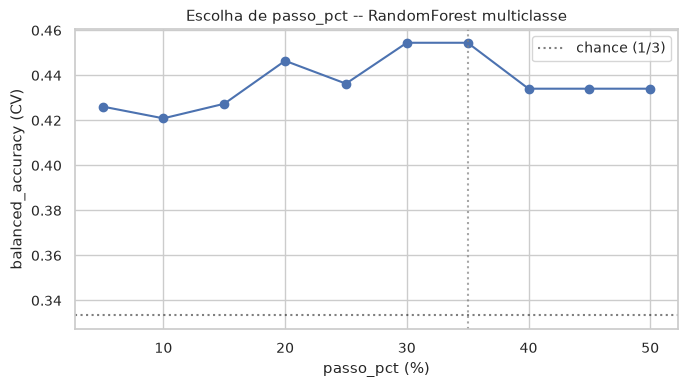


######################################################################
# RandomForest multiclasse -- Etapa 2/4: com vs. sem seleção de features
######################################################################
--- sem seleção de features (reaproveitado da Etapa 1, passo_pct=35%) ---
  [RandomForest multiclasse [sem seleção]] balanced_accuracy (CV): 0.454 | params: {'clf__class_weight': 'balanced', 'clf__criterion': 'entropy', 'clf__max_depth': 7, 'clf__max_features': 0.2, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}

--- com seleção de features ---
  [RandomForest multiclasse [com seleção]] grid com 1800 combinacoes -> GridSearchCV exaustivo
  [RandomForest multiclasse [com seleção]] melhor balanced_accuracy (CV): 0.458 | params: {'clf__class_weight': 'balanced', 'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 2, 'clf__n_estimators': 200, 'selector__max_featu

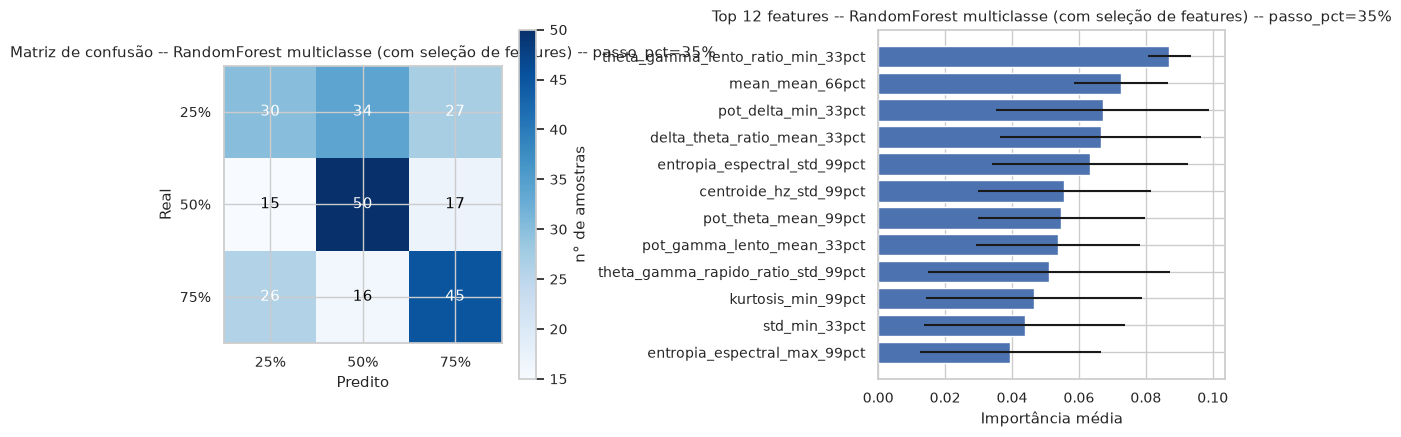


######################################################################
# RandomForest multiclasse -- Etapa 4/4: SHAP
######################################################################


Background dataset has 260 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=260 when initializing the masker.


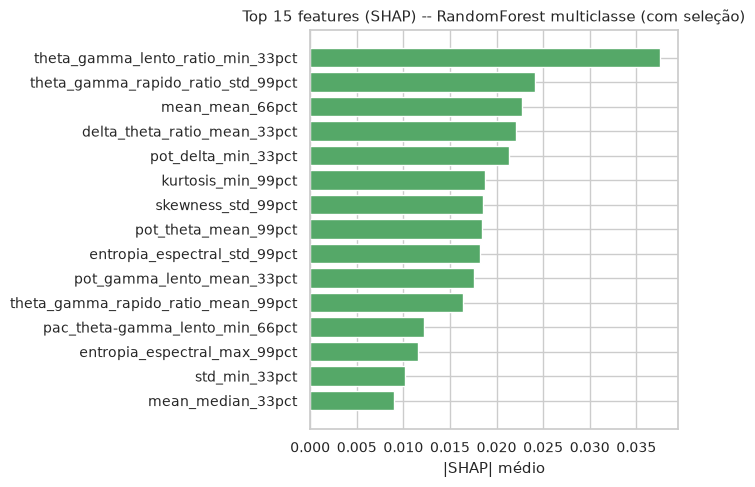

In [5]:
PARAM_GRID_RF_MEDIO_SEMSEL = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [2, 3, 5, 7, None],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [1, 5],
    "clf__max_features": ["sqrt", "log2", 0.2, 0.7, None],
    "clf__criterion": ["gini", "entropy", "log_loss"],
    "clf__class_weight": ["balanced"],
}


PARAM_GRID_RF_MEDIO_COMSEL = {
    "selector__max_features": TOP_N_FEATURES_GRID,
    **PARAM_GRID_RF_MEDIO_SEMSEL,
}

rf_base = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)

saida_rf = pipeline_completo_modelo(
    df_limpo, nome_modelo="RandomForest multiclasse", estimator=rf_base,
    param_grid_semsel=PARAM_GRID_RF_MEDIO_SEMSEL, param_grid_comsel=PARAM_GRID_RF_MEDIO_COMSEL,
)


## 6. Regressão Logística Multiclasse — Pipeline Completo

Mesma lógica da seção anterior, agora para `LogisticRegression`
(`class_weight="balanced"`, multinomial nativo via `lbfgs`), com grid mediano
próprio de `C`.


######################################################################
# Regressão Logística multiclasse -- Etapa 1/4: escolha de passo_pct (grid mediano)
######################################################################
  [Regressão Logística multiclasse [passo_pct=5]] grid com 512 combinacoes -> GridSearchCV exaustivo
  [Regressão Logística multiclasse [passo_pct=5]] melhor balanced_accuracy (CV): 0.405 | params: {'clf__C': 1, 'clf__class_weight': None, 'clf__fit_intercept': True, 'clf__max_iter': 3000, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'clf__tol': 0.01}
[Regressão Logística multiclasse] passo_pct=5 concluído em 1.0 min
  [Regressão Logística multiclasse [passo_pct=10]] grid com 512 combinacoes -> GridSearchCV exaustivo
  [Regressão Logística multiclasse [passo_pct=10]] melhor balanced_accuracy (CV): 0.349 | params: {'clf__C': 1, 'clf__class_weight': None, 'clf__fit_intercept': False, 'clf__max_iter': 3000, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'clf__tol': 0

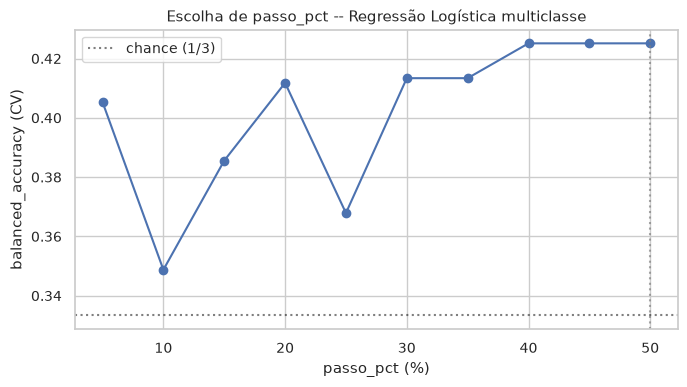


######################################################################
# Regressão Logística multiclasse -- Etapa 2/4: com vs. sem seleção de features
######################################################################
--- sem seleção de features (reaproveitado da Etapa 1, passo_pct=50%) ---
  [Regressão Logística multiclasse [sem seleção]] balanced_accuracy (CV): 0.425 | params: {'clf__C': 3, 'clf__class_weight': 'balanced', 'clf__fit_intercept': True, 'clf__max_iter': 3000, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'clf__tol': 0.01}

--- com seleção de features ---
  [Regressão Logística multiclasse [com seleção]] grid com 1536 combinacoes -> GridSearchCV exaustivo
  [Regressão Logística multiclasse [com seleção]] melhor balanced_accuracy (CV): 0.439 | params: {'clf__C': 3, 'clf__class_weight': 'balanced', 'clf__fit_intercept': True, 'clf__max_iter': 3000, 'clf__penalty': 'l2', 'clf__solver': 'newton-cg', 'clf__tol': 0.01, 'selector__max_features': 20}

[Regressão Logística m

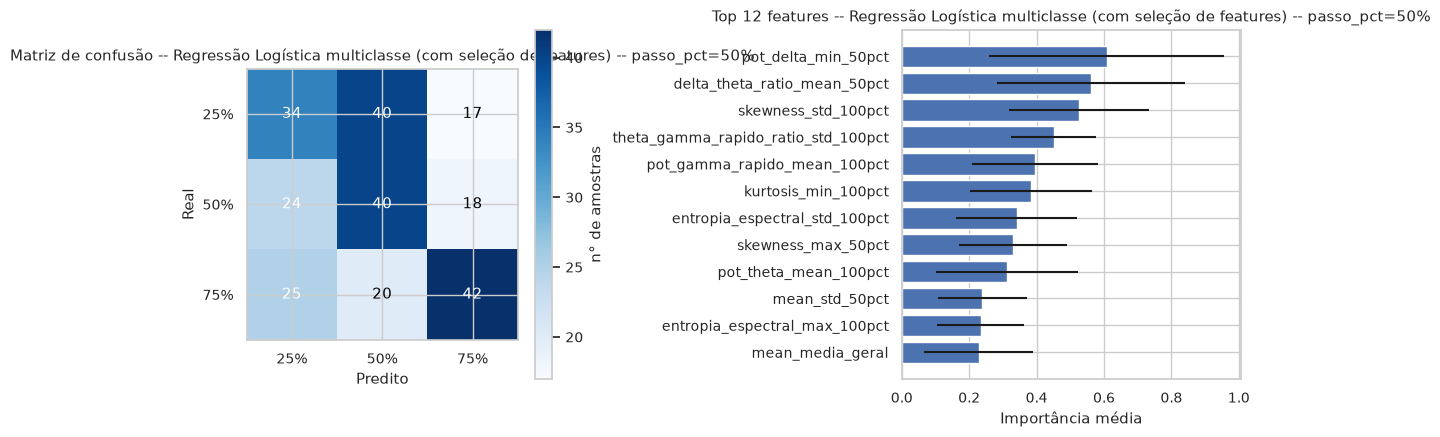


######################################################################
# Regressão Logística multiclasse -- Etapa 4/4: SHAP
######################################################################


Background dataset has 260 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=260 when initializing the masker.


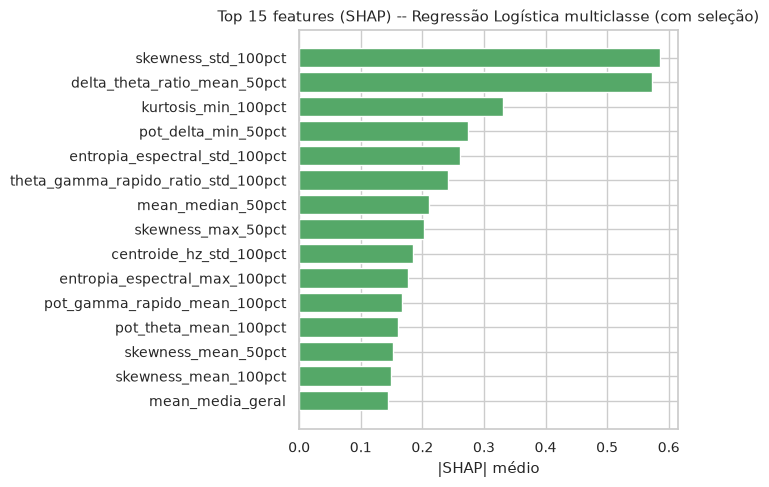

In [8]:
PARAM_GRID_LOGREG_MEDIO_SEMSEL = {
    "clf__C": [1e-4, 3e-4, 1, 3],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs", "newton-cg", "sag", "saga"],
    "clf__class_weight": [None, "balanced"],
    "clf__fit_intercept": [True, False],
    "clf__tol": [1e-2, 1e-3, 1e-4, 1e-5],
    "clf__max_iter": [3000, 5000],
}
PARAM_GRID_LOGREG_MEDIO_COMSEL = {
    "selector__max_features": TOP_N_FEATURES_GRID,
    **PARAM_GRID_LOGREG_MEDIO_SEMSEL,
}

logreg_base = LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE)

saida_logreg = pipeline_completo_modelo(
    df_limpo, nome_modelo="Regressão Logística multiclasse", estimator=logreg_base,
    param_grid_semsel=PARAM_GRID_LOGREG_MEDIO_SEMSEL, param_grid_comsel=PARAM_GRID_LOGREG_MEDIO_COMSEL,
)

## 7. XGBoost Multiclasse — Pipeline Completo

Mesmo esquema das seções anteriores, agora com `XGBClassifier`. O XGBoost
multiclasse espera rótulos codificados em `0..n_classes-1`, então os rótulos
(`25/50/75`) são recodificados via `y_transformer` só para esta seção; os
relatórios finais são traduzidos de volta para `%` via `inverse_label_fn`.

Diferente do RF/Regressão Logística (que usam `class_weight="balanced"`), o
`XGBClassifier` não tem um equivalente nativo simples para multiclasse — o
desbalanceamento de classes não é compensado automaticamente aqui.


######################################################################
# XGBoost multiclasse -- Etapa 1/4: escolha de passo_pct (grid mediano)
######################################################################
  [XGBoost multiclasse [passo_pct=5]] grid com 972 combinacoes -> GridSearchCV exaustivo
  [XGBoost multiclasse [passo_pct=5]] melhor balanced_accuracy (CV): 0.415 | params: {'clf__colsample_bytree': 0.6, 'clf__gamma': 0.5, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__subsample': 0.6}
[XGBoost multiclasse] passo_pct=5 concluído em 12.1 min
  [XGBoost multiclasse [passo_pct=10]] grid com 972 combinacoes -> GridSearchCV exaustivo
  [XGBoost multiclasse [passo_pct=10]] melhor balanced_accuracy (CV): 0.417 | params: {'clf__colsample_bytree': 0.6, 'clf__gamma': 0, 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
[XGBoost multiclasse] passo_pc

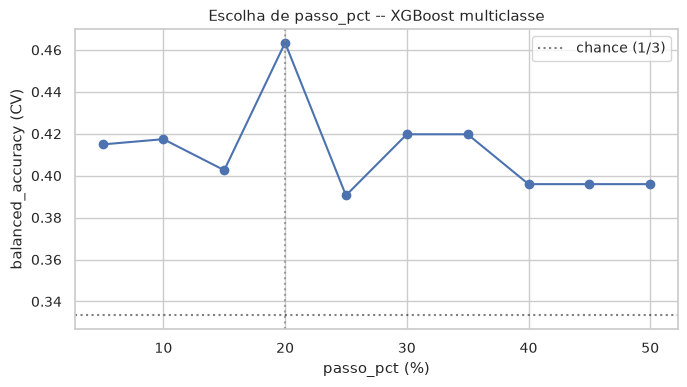


######################################################################
# XGBoost multiclasse -- Etapa 2/4: com vs. sem seleção de features
######################################################################
--- sem seleção de features (reaproveitado da Etapa 1, passo_pct=20%) ---
  [XGBoost multiclasse [sem seleção]] balanced_accuracy (CV): 0.463 | params: {'clf__colsample_bytree': 1.0, 'clf__gamma': 0, 'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__subsample': 1.0}

--- com seleção de features ---
  [XGBoost multiclasse [com seleção]] grid com 2916 combinacoes -> GridSearchCV exaustivo
  [XGBoost multiclasse [com seleção]] melhor balanced_accuracy (CV): 0.420 | params: {'clf__colsample_bytree': 1.0, 'clf__gamma': 0, 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__min_child_weight': 5, 'clf__n_estimators': 100, 'clf__subsample': 1.0, 'selector__max_features': 20}

[XGBoost multiclasse] vencedor: SEM seleção de featu

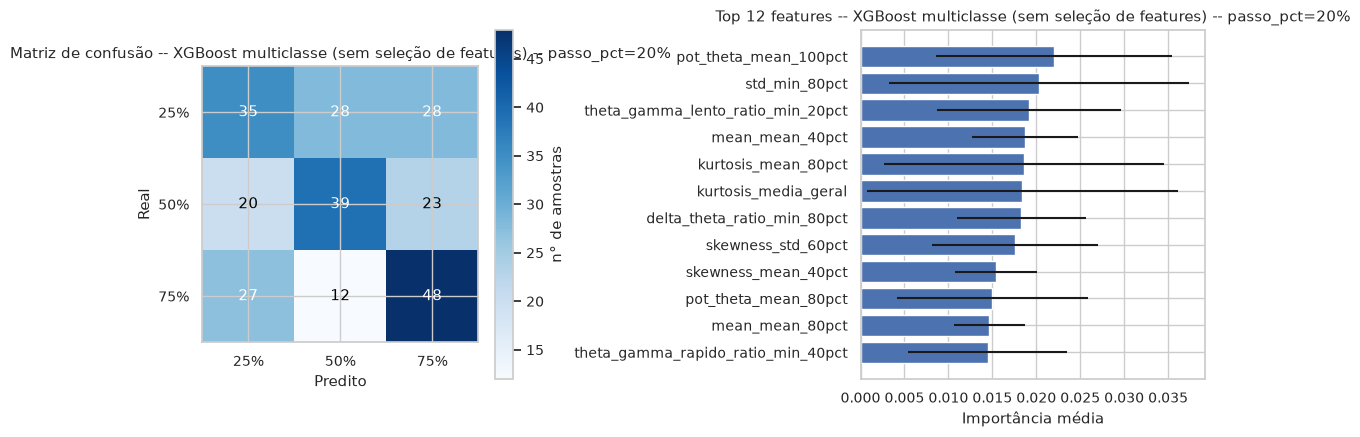


######################################################################
# XGBoost multiclasse -- Etapa 4/4: SHAP
######################################################################

######################################################################
# XGBoost multiclasse -- SHAP (TreeExplainer, tree_path_dependent)
######################################################################


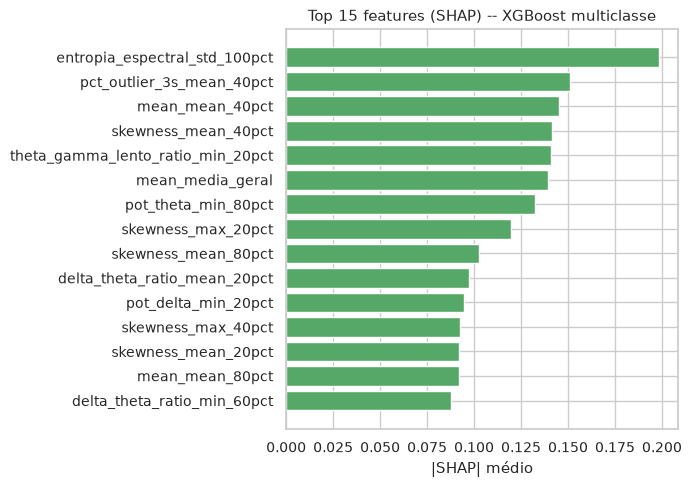

In [12]:
if XGBOOST_DISPONIVEL:
    MAPA_XGB = {c: i for i, c in enumerate(CONDICOES_ALVO)}
    MAPA_XGB_INV = {i: c for c, i in MAPA_XGB.items()}

    def codificar_y_xgb(y_multi):
        return y_multi.map(MAPA_XGB)

    def decodificar_y_xgb(labels_codificados):
        return [MAPA_XGB_INV[l] for l in labels_codificados]

    PARAM_GRID_XGB_MEDIO_SEMSEL = {
        "clf__n_estimators": [100, 200],                
        "clf__max_depth": [2, 3, 5],                        # 5
        "clf__learning_rate": [0.03, 0.1],            # 4
        "clf__subsample": [0.6, 0.8, 1.0],                        # 3
        "clf__colsample_bytree": [0.6, 0.8, 1.0],                 # 3
        "clf__min_child_weight": [1, 3, 5],                       # 3
        "clf__gamma": [0, 0.5, 1],                               # 3
    }

    PARAM_GRID_XGB_MEDIO_COMSEL = {
        "selector__max_features": TOP_N_FEATURES_GRID,
        **PARAM_GRID_XGB_MEDIO_SEMSEL,
    }

    xgb_base = XGBClassifier(
        objective="multi:softprob", num_class=len(CONDICOES_ALVO),
        eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1,
        tree_method="hist",
    )

    saida_xgb = pipeline_completo_modelo(
        df_limpo, nome_modelo="XGBoost multiclasse", estimator=xgb_base,
        param_grid_semsel=PARAM_GRID_XGB_MEDIO_SEMSEL, param_grid_comsel=PARAM_GRID_XGB_MEDIO_COMSEL,
        y_transformer=codificar_y_xgb, inverse_label_fn=decodificar_y_xgb,
        calcular_shap_flag=False,
    )

    print(f"\n{'#'*70}\n# XGBoost multiclasse -- SHAP (TreeExplainer, tree_path_dependent)\n{'#'*70}")
    if SHAP_DISPONIVEL:
        pipe_xgb = saida_xgb["pipe_final"]
        X_final_xgb = saida_xgb["X_final"]

        X_proc_xgb = X_final_xgb
        for _, passo in pipe_xgb.steps[:-1]:
            X_proc_xgb = passo.transform(X_proc_xgb)
        selector_xgb = pipe_xgb.named_steps.get("selector")
        feats_xgb = (
            X_final_xgb.columns[selector_xgb.get_support()]
            if selector_xgb is not None else X_final_xgb.columns
        )
        X_proc_xgb = pd.DataFrame(np.asarray(X_proc_xgb), columns=feats_xgb, index=X_final_xgb.index)

        n_amostra_xgb = min(200, len(X_proc_xgb))
        X_amostra_xgb = (
            X_proc_xgb.sample(n_amostra_xgb, random_state=RANDOM_STATE)
            if len(X_proc_xgb) > n_amostra_xgb else X_proc_xgb
        )

        explainer_xgb = shap.TreeExplainer(
            pipe_xgb.named_steps["clf"], feature_perturbation="tree_path_dependent"
        )
        valores_shap_xgb = explainer_xgb(X_amostra_xgb)

        valores_xgb = valores_shap_xgb.values
        valores_abs_medios_xgb = (
            np.abs(valores_xgb).mean(axis=(0, 2)) if valores_xgb.ndim == 3
            else np.abs(valores_xgb).mean(axis=0)
        )
        resumo_shap_xgb = pd.Series(valores_abs_medios_xgb, index=feats_xgb).sort_values(ascending=False)

        fig, ax = plt.subplots(figsize=(7, 5))
        top_shap_xgb = resumo_shap_xgb.head(15).iloc[::-1]
        ax.barh(top_shap_xgb.index, top_shap_xgb.values, color="#55A868")
        ax.set_xlabel("|SHAP| médio")
        ax.set_title("Top 15 features (SHAP) -- XGBoost multiclasse")
        plt.tight_layout()
        plt.show()

        saida_xgb["resumo_shap"] = resumo_shap_xgb
    else:
        print("shap não disponível -- pulando etapa de SHAP.")
        saida_xgb["resumo_shap"] = None
else:
    saida_xgb = None
    print("Pulando seção XGBoost -- pacote 'xgboost' não disponível (pip install xgboost).")


## 8. Teste de Permutação — existe sinal acima do acaso? (RF)

Embaralha os rótulos e repete a avaliação completa via Leave-One-Rat-Out
`n_permutacoes` vezes, construindo a distribuição nula de `balanced_accuracy`.
O p-valor é a fração das permutações que igualam ou superam o resultado
observado com os rótulos verdadeiros — importante com poucos grupos (ratos)
no CV.

Ajuste `n_permutacoes` para baixo (ex. 50) para uma checagem rápida, ou para
cima (ex. 500-1000) para um p-valor mais preciso ao reportar no texto final.

    [RF multiclasse (observado)] fold 1/7 -- teste = rato R1 (n=18) | bal_acc=0.321 | f1_macro=0.250
    [RF multiclasse (observado)] fold 2/7 -- teste = rato R2 (n=48) | bal_acc=0.438 | f1_macro=0.412
    [RF multiclasse (observado)] fold 3/7 -- teste = rato R3 (n=41) | bal_acc=0.657 | f1_macro=0.650
    [RF multiclasse (observado)] fold 4/7 -- teste = rato R4 (n=44) | bal_acc=0.569 | f1_macro=0.571
    [RF multiclasse (observado)] fold 5/7 -- teste = rato R5 (n=48) | bal_acc=0.500 | f1_macro=0.404
    [RF multiclasse (observado)] fold 6/7 -- teste = rato R7 (n=32) | bal_acc=0.454 | f1_macro=0.417
    [RF multiclasse (observado)] fold 7/7 -- teste = rato R8 (n=29) | bal_acc=0.264 | f1_macro=0.212
  [RF multiclasse] permutação 50/200...
  [RF multiclasse] permutação 100/200...
  [RF multiclasse] permutação 150/200...
  [RF multiclasse] permutação 200/200...

[RF multiclasse] balanced_accuracy observado: 0.458
[RF multiclasse] balanced_accuracy nulo (média ± dp): 0.333 ± 0.036
[RF multi

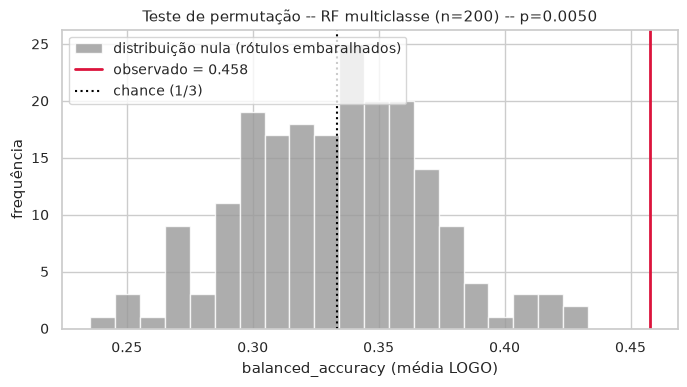

In [17]:
def teste_permutacao_multiclasse(X, y_multi, groups, logo, estimator, melhores_params,
                                  n_permutacoes=200, usar_selecao_features=True,
                                  selector_estimator=None, random_state=RANDOM_STATE,
                                  rotulo="modelo"):
    rng = np.random.RandomState(random_state)

    resultado_real = treinar_avaliar_multiclasse(
        X, y_multi, groups, logo, estimator, melhores_params,
        usar_selecao_features, selector_estimator, rotulo=f"{rotulo} (observado)",
    )
    bal_acc_observado = resultado_real["df_resultados"]["balanced_accuracy"].mean()

    bal_acc_nulo = []
    for i in range(n_permutacoes):
        y_perm = pd.Series(rng.permutation(y_multi.values), index=y_multi.index)
        bal_accs_fold = []
        for idx_tr, idx_te in logo.split(X, y_perm, groups=groups):
            X_tr, X_te = X.iloc[idx_tr], X.iloc[idx_te]
            y_tr, y_te = y_perm.iloc[idx_tr], y_perm.iloc[idx_te]
            pipe = montar_pipeline_multiclasse(clone(estimator), usar_selecao_features, selector_estimator)
            pipe.set_params(**melhores_params)
            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_te)
            # ver nota em treinar_avaliar_multiclasse sobre o UserWarning benigno
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=UserWarning)
                bal_accs_fold.append(balanced_accuracy_score(y_te, y_pred))
        bal_acc_nulo.append(np.mean(bal_accs_fold))
        if (i + 1) % 50 == 0:
            print(f"  [{rotulo}] permutação {i+1}/{n_permutacoes}...")

    bal_acc_nulo = np.array(bal_acc_nulo)
    p_valor = (np.sum(bal_acc_nulo >= bal_acc_observado) + 1) / (n_permutacoes + 1)

    print(f"\n[{rotulo}] balanced_accuracy observado: {bal_acc_observado:.3f}")
    print(f"[{rotulo}] balanced_accuracy nulo (média ± dp): {bal_acc_nulo.mean():.3f} ± {bal_acc_nulo.std():.3f}")
    print(f"[{rotulo}] p-valor (permutação, n={n_permutacoes}): {p_valor:.4f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(bal_acc_nulo, bins=20, color="#999999", alpha=0.8, label="distribuição nula (rótulos embaralhados)")
    ax.axvline(bal_acc_observado, color="crimson", linewidth=2, label=f"observado = {bal_acc_observado:.3f}")
    ax.axvline(1 / 3, color="black", linestyle=":", label="chance (1/3)")
    ax.set_xlabel("balanced_accuracy (média LOGO)")
    ax.set_ylabel("frequência")
    ax.set_title(f"Teste de permutação -- {rotulo} (n={n_permutacoes}) -- p={p_valor:.4f}")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return {"bal_acc_observado": bal_acc_observado, "bal_acc_nulo": bal_acc_nulo, "p_valor": p_valor}


# Ajuste n_permutacoes conforme o tempo disponível (200 já dá um p-valor razoável).
logo = LeaveOneGroupOut()
resultado_permutacao_rf = teste_permutacao_multiclasse(
    saida_rf["X_final"], saida_rf["y_multi"], saida_rf["groups"], logo, rf_base,
    saida_rf["melhores_params"], n_permutacoes=200,
    usar_selecao_features=saida_rf["usa_selecao_features"], rotulo="RF multiclasse",
)


O classificador Random Forest foi avaliado por validação cruzada Leave-One-Group-Out (LOGO), utilizando cada rato como conjunto de teste. O desempenho médio obtido foi de **balanced accuracy = 0.458**, superior ao esperado pelo acaso (**0.333**). O teste de permutação com **200 permutações** resultou em uma distribuição nula de **0.333 ± 0.036** e **p = 0.005**, indicando que o desempenho observado é estatisticamente significativo. Embora exista variação entre os animais, os resultados demonstram que o modelo foi capaz de identificar padrões reais nos dados, com desempenho acima do esperado por classificações aleatórias.

In [ ]:
from sklearn.metrics import precision_recall_fscore_support


def metricas_por_classe_logo(X, y_multi, groups, estimator, melhores_params,
                              usar_selecao_features, labels_multi, rotulos_exibicao, nome_modelo):
    """Roda o Leave-One-Rat-Out de novo (reaproveitando os hiperparâmetros já
    escolhidos -- sem busca de grid) só para juntar y_true/y_pred de todos os
    folds e calcular precisão, revocação e F1 por classe."""
    logo = LeaveOneGroupOut()
    y_true_all, y_pred_all = [], []

    for idx_tr, idx_te in logo.split(X, y_multi, groups=groups):
        X_tr, X_te = X.iloc[idx_tr], X.iloc[idx_te]
        y_tr, y_te = y_multi.iloc[idx_tr], y_multi.iloc[idx_te]

        pipe = montar_pipeline_multiclasse(clone(estimator), usar_selecao_features)
        pipe.set_params(**melhores_params)
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)

        y_true_all.extend(y_te.tolist())
        y_pred_all.extend(y_pred.tolist())

    precisao, revocacao, f1, suporte = precision_recall_fscore_support(
        y_true_all, y_pred_all, labels=labels_multi, average=None, zero_division=0
    )

    df_metricas = pd.DataFrame({
        "classe": rotulos_exibicao,
        "precisao": precisao, "revocacao": revocacao, "f1": f1, "suporte": suporte,
    })
    df_metricas.insert(0, "modelo", nome_modelo)

    print(f"\n=== Métricas por classe -- {nome_modelo} (agregado via LOGO) ===")
    display(df_metricas.set_index("classe").round(3))
    return df_metricas


metricas_rf = metricas_por_classe_logo(
    saida_rf["X_final"], saida_rf["y_multi"], saida_rf["groups"],
    estimator=saida_rf["pipe_final"].named_steps["clf"], melhores_params=saida_rf["melhores_params"],
    usar_selecao_features=saida_rf["usa_selecao_features"],
    labels_multi=sorted(saida_rf["y_multi"].unique()), rotulos_exibicao=saida_rf["resultado"]["labels"],
    nome_modelo="RandomForest",
)

metricas_logreg = metricas_por_classe_logo(
    saida_logreg["X_final"], saida_logreg["y_multi"], saida_logreg["groups"],
    estimator=saida_logreg["pipe_final"].named_steps["clf"], melhores_params=saida_logreg["melhores_params"],
    usar_selecao_features=saida_logreg["usa_selecao_features"],
    labels_multi=sorted(saida_logreg["y_multi"].unique()), rotulos_exibicao=saida_logreg["resultado"]["labels"],
    nome_modelo="Regressão Logística",
)

if saida_xgb is not None:
    metricas_xgb = metricas_por_classe_logo(
        saida_xgb["X_final"], saida_xgb["y_multi"], saida_xgb["groups"],
        estimator=saida_xgb["pipe_final"].named_steps["clf"], melhores_params=saida_xgb["melhores_params"],
        usar_selecao_features=saida_xgb["usa_selecao_features"],
        labels_multi=sorted(saida_xgb["y_multi"].unique()), rotulos_exibicao=saida_xgb["resultado"]["labels"],
        nome_modelo="XGBoost",
    )
    metricas_todas = pd.concat([metricas_rf, metricas_logreg, metricas_xgb], ignore_index=True)
else:
    metricas_todas = pd.concat([metricas_rf, metricas_logreg], ignore_index=True)

print("\n=== Comparação lado a lado -- F1 por classe ===")
display(metricas_todas.pivot(index="classe", columns="modelo", values="f1").round(3))

metricas_todas.to_csv(pasta_multiclasse / "metricas_por_classe_todos_modelos.csv", index=False)
print(f"\nSalvo em: {pasta_multiclasse / 'metricas_por_classe_todos_modelos.csv'}")


=== Métricas por classe -- RandomForest (agregado via LOGO) ===


,modelo,precisao,revocacao,f1,suporte
classe,,,,,
25%,RandomForest,0.423,0.330,0.370,91
50%,RandomForest,0.500,0.610,0.549,82
75%,RandomForest,0.506,0.517,0.511,87



=== Métricas por classe -- Regressão Logística (agregado via LOGO) ===


,modelo,precisao,revocacao,f1,suporte
classe,,,,,
25%,Regressão Logística,0.410,0.374,0.391,91
50%,Regressão Logística,0.400,0.488,0.440,82
75%,Regressão Logística,0.545,0.483,0.512,87


In [18]:
PARAM_GRID_RF_AREA = PARAM_GRID_RF_MEDIO_COMSEL if saida_rf["usa_selecao_features"] else PARAM_GRID_RF_MEDIO_SEMSEL

X_final_rf = saida_rf["X_final"]
y_multi_rf = saida_rf["y_multi"]
groups_rf = saida_rf["groups"]

resultados_por_area = {}

for area in AREAS:
    col_area = f"area_{area}"
    if col_area not in X_final_rf.columns:
        continue

    mask = X_final_rf[col_area] == 1
    cols_area_dummy = [c for c in X_final_rf.columns if c.startswith("area_")]
    X_area = X_final_rf.loc[mask].drop(columns=cols_area_dummy)
    y_area = y_multi_rf.loc[mask]
    groups_area = groups_rf.loc[mask]

    n_ratos_area = groups_area.nunique()
    if n_ratos_area < 3 or y_area.nunique() < 2:
        print(f"[{area}] amostras insuficientes (ratos={n_ratos_area}, classes={y_area.nunique()}) -- pulando.")
        continue

    logo_area = LeaveOneGroupOut()
    print(f"\n{'='*60}\nÁrea: {area} (n={len(X_area)} linhas, {n_ratos_area} ratos)\n{'='*60}")

    params_area, _ = escolher_melhores_hiperparametros_multi(
        X_area, y_area, groups_area, logo_area,
        estimator=RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        param_grid=PARAM_GRID_RF_AREA, usar_selecao_features=saida_rf["usa_selecao_features"],
        rotulo=f"RF multiclasse [{area}]",
    )
    resultado_area = treinar_avaliar_multiclasse(
        X_area, y_area, groups_area, logo_area,
        estimator=RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        melhores_params=params_area, usar_selecao_features=saida_rf["usa_selecao_features"],
        rotulo=f"RF multiclasse [{area}]",
    )
    resultados_por_area[area] = resultado_area

comparacao_areas = pd.DataFrame({
    area: {
        "balanced_accuracy_media": r["df_resultados"]["balanced_accuracy"].mean(),
        "balanced_accuracy_dp": r["df_resultados"]["balanced_accuracy"].std(),
        "n_ratos": r["df_resultados"]["rato_teste"].nunique(),
    }
    for area, r in resultados_por_area.items()
}).T.sort_values("balanced_accuracy_media", ascending=False)

print("\nComparação de balanced_accuracy por área anatômica (RF multiclasse):")
display(comparacao_areas.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(comparacao_areas.index, comparacao_areas["balanced_accuracy_media"],
       yerr=comparacao_areas["balanced_accuracy_dp"], color="#4C72B0")
ax.axhline(1 / 3, color="black", linestyle=":", label="chance (1/3)")
ax.set_ylabel("balanced_accuracy")
ax.set_title("Balanced accuracy por área anatômica -- RF multiclasse")
ax.legend()
plt.tight_layout()
plt.show()



Área: CA3b (n=59 linhas, 7 ratos)
  [RF multiclasse [CA3b]] grid com 1800 combinacoes -> GridSearchCV exaustivo


KeyboardInterrupt: 